# Hybrid Modulear Field Toy with Closure Diagnostics: 
## When Do Local Rules Generate Fields That Remember Themselves?

> *Time supplies content &mdash; space supplies measure.*  
> -Arthur M. Young, <u>The Geometry of Meaning</u>

### First Things, First
**The field is a 1-D modular lattice evolving over discrete time.** The system is defined on a lattic of $\mathtt{n cells}$, where each cell holds an integer state in the range $\mathtt{[0,\;m-1]}$

$$  
\begin{matrix}
    \mathtt{time\to}  \\
    t0 & . & . & . & 1 & . & . & .  \\
    t1 & . & . & 2 & 3 & 2 & . & .  \\
    t2 & . & 4 & 5 & 6 & 5 & 4 & .  \\
    t3 & 2 & 3 & 1 & 0 & 1 & 3 & 2
\end{matrix}
$$

* Each row is a state vector $$\mathtt{s(t)} = \mathtt{[s1, s2. s3, ...sn]}$$
* And *the simulation becomes a matrix*: $$\mathtt{field.shape} = \mathtt{(timesteps, cells)}$$
* The matrix is the object every metric will analyze, so the simulator only needs to do one thing well: $$\mathtt{generateField()}$$
------------------------------------------------------------------------------------------

### Second 
At each timestep, the state of every cell is updated according to a local interaction rule:  $$\mathtt{s_{t+1,i}} = \mathtt{(a\;\cdot\;N_{t,i}\;+\;b)\;\;mod}\;m$$  
where the neighborhood function is: $$\mathtt{N_{t,i}} = \mathtt{s_{i-1} \; + \; s_{i} \; +\; s_{i+1}}$$

------------------------------------------------------------------------------------------

#### Three things are happening here:
1. **Cellular Dynamics** ~ local interaction: each cell only sees it's neighbors.
2. **Linear Transformation** ~ the rule parameter: a * neighborhood + b
3. **Modular Projection** ~ $\mathtt{mod}\;m$: folds the system back into finite state space, creating cycles. With it, the system must eventually recur.  

*Does it recure in a structured way?*  

------------------------------------------------------------------------------------------

This defined a closed, deterministic system:
- no extrernal inputs
- no stochasticity
- all evolution arises from local interactions and modular constraints

An initial condition&mdash; typically a single impulse, is used to seed the system and the field is evolved over a fixed number of timesteps.

Te result is a 2D Field: 
- rows = time
- columns = spatial position
- values = discrete modular states

## Diagnostics

to analyze the behavior of the field, several metrics are computed at each timestep:

#### Entropy
Measures the distribution of states within a row. Hogher entropy indicates aligned or slowly varying regions; low coherence indicates fragmentation.

#### Coherence
Measures local smoothness by comparing each cell to its neighbor. High coherence indicates aligned or slowly varying regions, while low coherence indicates fragmentation or rapid change.

#### Closure 
Evaluates how similar the current state is to previous states across different time lags. This reveals whether the system revisits earlier configurations.

#### Closure Lag Spectrum
This extends by computing simiarity across all lags and timesteps. this shows how memory is distributed and whether specific recurrence intervals emerge.

#### Dominant Lag
The dominant lag identifies, for each timestep, the lag with the highest similarity. This provides a direct estimate of the system's recurrence length.

#### Reconstruction Coherence
Tests whether recurrence is dynamic. If  past state resembles the present, this metric checks whether its next state also resembles the present's next state. This distinguishes superficial similarity from true structural recurrence.

#### Structural Compression Ratio
This ratio measures how compressible each row is using a standard compression algorith. Lower values indicate redundancy and regular structure, while higher values indicate more complex or less stuctured patterns.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np

from simulate import run_simulation
from metrics import(
    field_entropy,
    field_coherence,
    closure_index,
    closure_spectrum,
    best_lag,
    reconstruction_coherence,
    field_compression
)

from plots import(
    plot_field_2d,
    plot_entropy,
    plot_coherence,
    plot_reconstruction,
    plot_compression,
    plot_diagnostic_panel
)


In [2]:
# parameters

n_cells = 128
steps = 160

a = 2
b= 1
m= 7

In [3]:
# initial condition
state0 = np.zeros(n_cells, dtype=int)
state0[n_cells // 2] = 1

In [4]:
# run simulation

field = run_simulation(state0, steps, a, b, m)
field.shape

(160, 128)

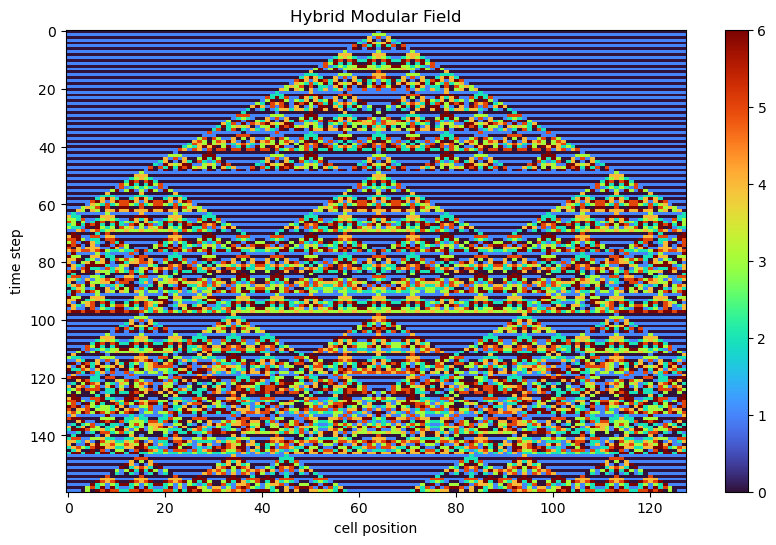

In [5]:
# field visualization

plot_field_2d(field, m)

*The color bar is mapping from color $\to$ numeric value*   

Each pixel in the plot is $\mathtt{field [t, i]}$  
* row $\to$ time step $\mathtt{t}
* column $\to$ cell position $\mathtt{i}
* color $\to$ value of that cell


In [6]:
# diagnostics

entropy_curve = field_entropy(field, m)
coherence_curve = field_coherence(field, m)
closure_curve = closure_index(field, m, max_lag=40)
recon_curve = reconstruction_coherence(field, m, max_lag=40)
compression_curve = field_compression(field)

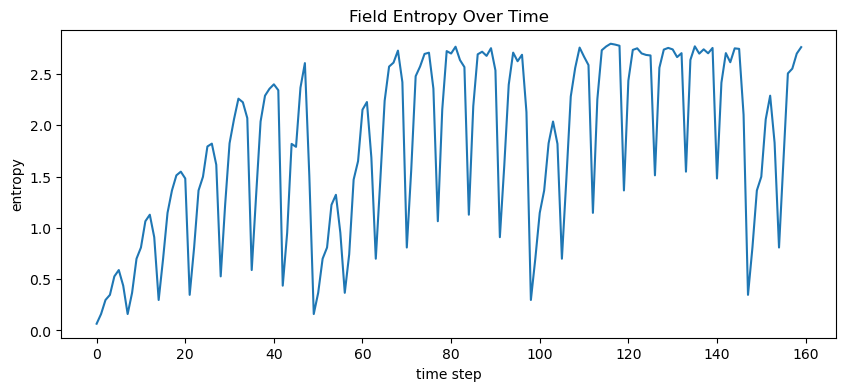

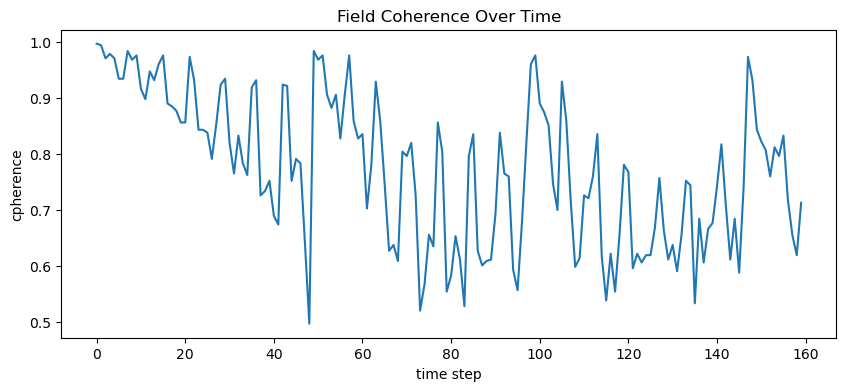

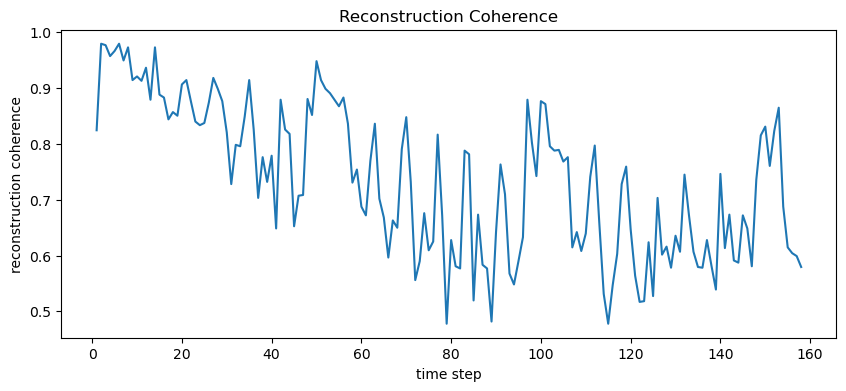

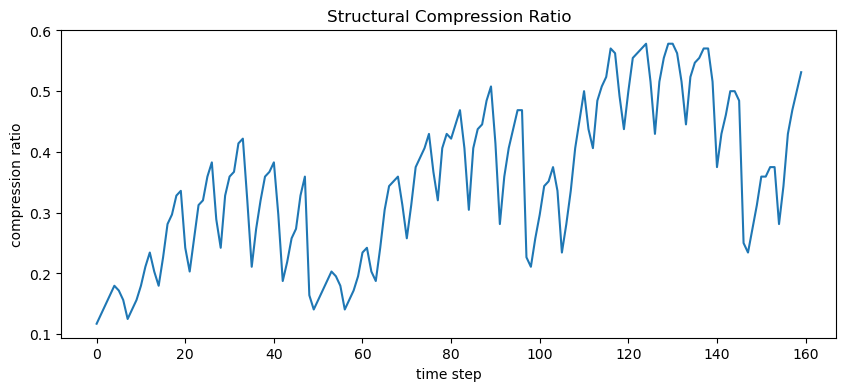

In [7]:
# diagnostics plots

plot_entropy(entropy_curve)
plot_coherence(coherence_curve)
plot_reconstruction(recon_curve)
plot_compression(compression_curve)

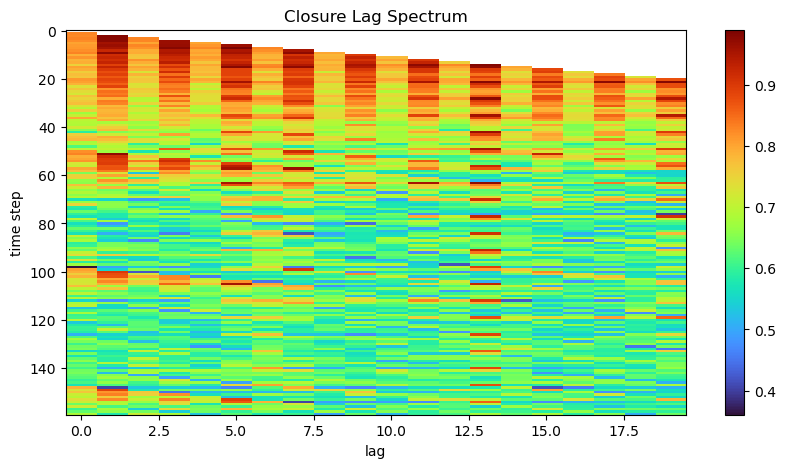

In [8]:
# closure spectrum

spec = closure_spectrum(field, m, max_lag=20)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.imshow(spec, aspect='auto', cmap='turbo', interpolation='nearest')
plt.colorbar()
plt.xlabel("lag")
plt.ylabel("time step")
plt.title("Closure Lag Spectrum")
plt.show()

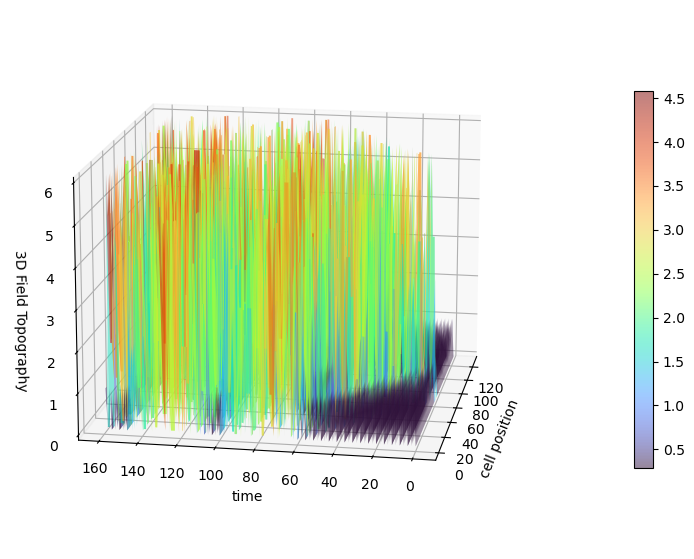

In [9]:
x = np.arange(field.shape[1])  # cell positions
y = np.arange(field.shape[0]) # time steps

X, Y = np.meshgrid(x, y)

fig = plt.figure(figsize=(11, 7))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(
    X, Y, field,
    cmap ='turbo',
    alpha=0.5
)
ax.view_init(elev=15, azim=-170)
#ax.set_zlim(0, 6)
ax.set_xlabel("cell position")
ax.set_ylabel("time")
ax.set_zlabel("3D Field Topography")

fig.colorbar(surf, ax=ax, shrink=0.7, pad=0.1)
plt.show()

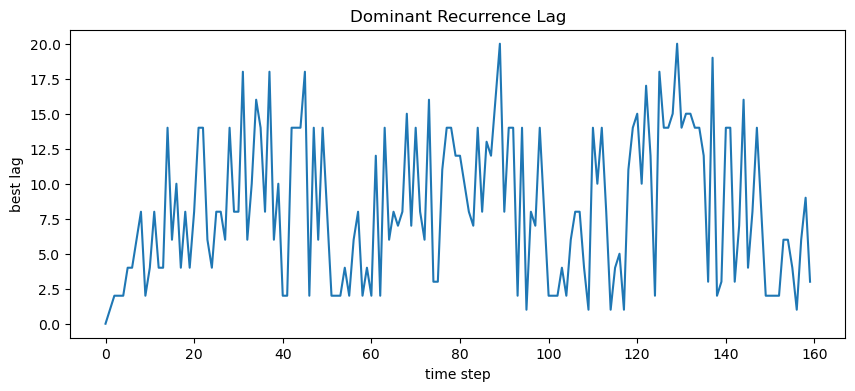

In [10]:

lag_curve = best_lag(field, m, max_lag=20)

plt.figure(figsize=(10, 4))
plt.plot(lag_curve)
plt.xlabel("time step")
plt.ylabel("best lag")
plt.title("Dominant Recurrence Lag")
plt.show()

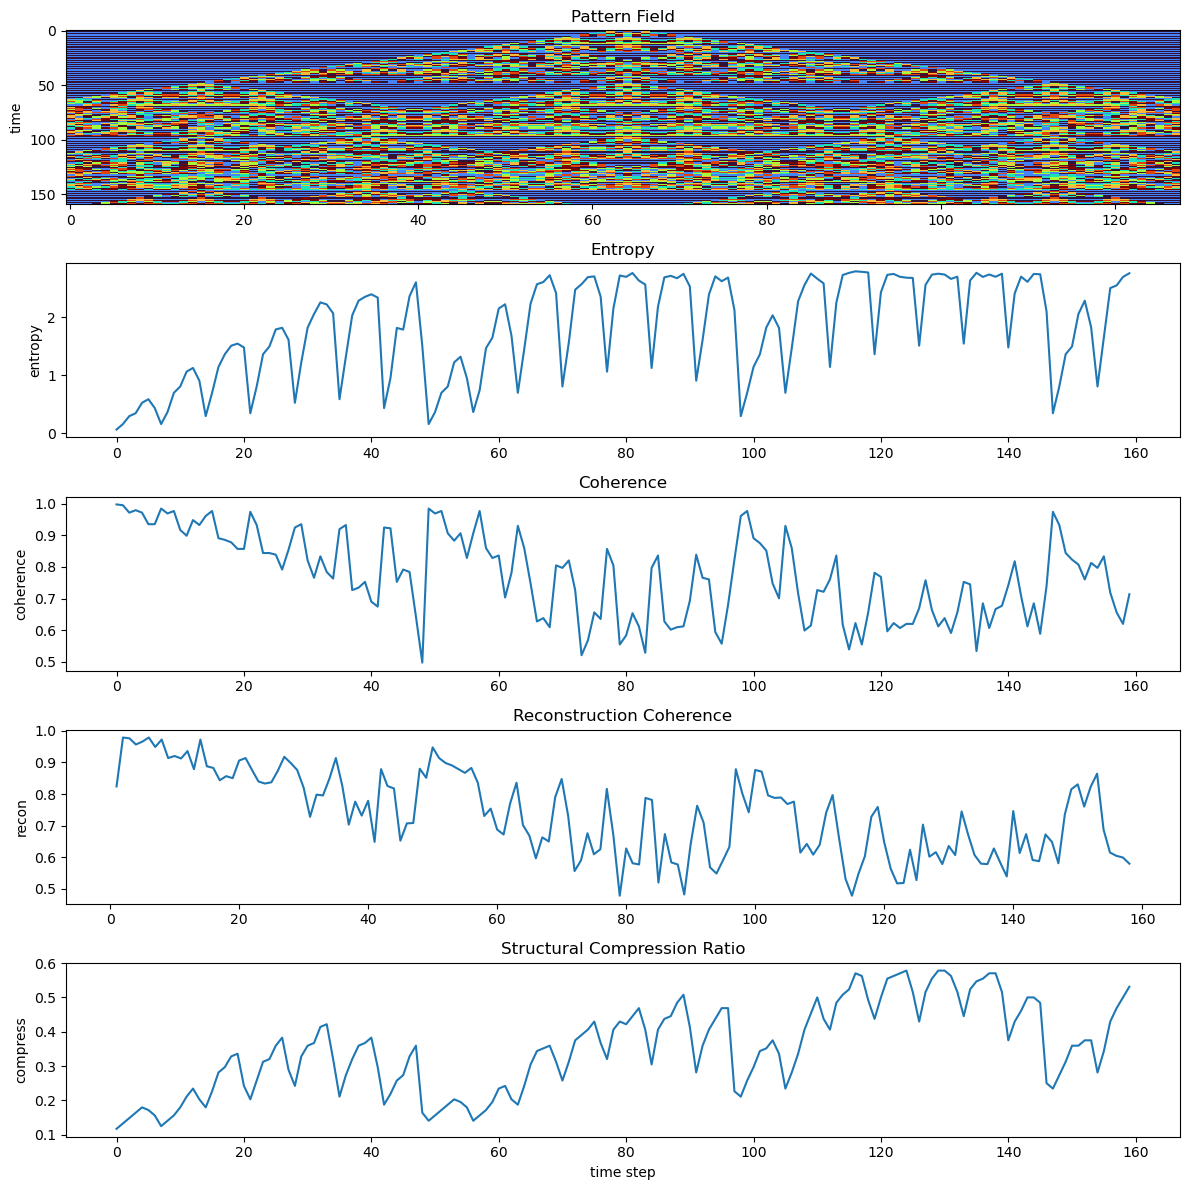

In [11]:
plot_diagnostic_panel(
    field,
    entropy_curve,
    coherence_curve,
    recon_curve,
    compression_curve,
    m
)

## Observations (This Run)

Starting from a single impulse initial condition, the system exhibits structured expansion followed by the emergence of recurring patterns.   

A dominant recurrence length of approxiamtely 14 timesteps emerges. his is visible in the closure las spectrum as a strong vertical band and in the dominant lag curve, which stabalizes around this value.  

After an initial transiet phase, the system locks into this recurrence interval, indicating stable cyclical behavior.  

Reconstruction coherence rises and remains high after this lock-in. This shows that the system is not only repeating configurations, but also repeating its tranisition dynamics.  

Entropy increases during early expansion, then fluctuaties as the system enters a structured regime. Cohwrwnce shows complimentary behavior, reflecting alternating phases of alignment and variation.  

The compression ratio decreases as the system stabalizes, indicating increasing structural redundancy and pattern regularity.  

Overall, the system demonstrates emergent periodicity, persistemt structural memory, and stable dynamic recurrence arising from simple local rules.

In [12]:
import numpy as np
import plotly.graph_objects as go

x = np.arange(field.shape[1])   # cell position
y = np.arange(field.shape[0])   # time step
X, Y = np.meshgrid(x, y)

fig = go.Figure(
    data=[
        go.Surface(
            x=X,
            y=Y,
            z=field,
            colorscale="Turbo",
            contours={
                "z":{
                    "show": True,
                    "usecolormap":True,
                    "project_z": True
                }
            }
        )
    ]
)

fig.update_layout(
    title="3D Field Topography",
    scene=dict(
        xaxis_title="cell position",
        yaxis_title="time step",
        zaxis_title="state value",
        camera=dict(
            eye=dict(x=-1.8, y=-0.3, z=0.6)
        )
    ),
    width=950,
    height=700
)

fig.show()
fig.write_html("field_3d.html", include_plotlyjs="cdn")
fig.write_image("field_3d.png")

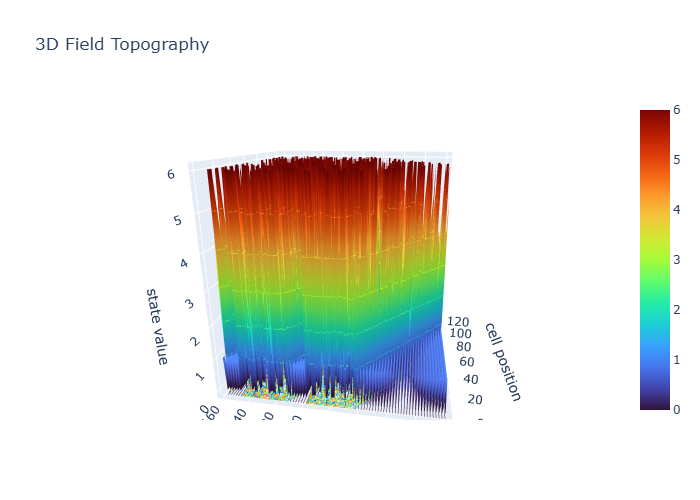

In [14]:
from IPython.display import Image
Image("field_3d.png")